In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
df = pd.read_csv("ecommerce_sales_data.csv")
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["Revenue"] = (
    df["Quantity"] *
    df["Price"] *
    (1 - df["Discount"]/100)
)

df["Month"] = df["TransactionDate"].dt.month_name()

df["Year"] = df["TransactionDate"].dt.year
print(df)

       TransactionID  CustomerID  ProductID ProductCategory  Quantity   Price  \
0                  1        8270        295        Clothing         1  801.66   
1                  2        1860        546          Beauty         1  225.03   
2                  3        6390        430            Toys         2  544.99   
3                  4        6191        807          Beauty         2  157.02   
4                  5        6734        319     Electronics         2  155.51   
...              ...         ...        ...             ...       ...     ...   
99995          99996        4411        921        Clothing         4  921.41   
99996          99997        5136        606     Electronics         4  130.52   
99997          99998        1966        408           Books         3  231.39   
99998          99999        2751        166           Books         4   11.75   
99999         100000        5836        548     Electronics         4  807.39   

       Discount     Transac

In [6]:
category_sales = (
    df.groupby("ProductCategory")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

ProductCategory
Books             1.811082e+07
Clothing          1.809279e+07
Toys              1.786311e+07
Beauty            1.785834e+07
Home & Kitchen    1.785665e+07
Sports            1.785606e+07
Electronics       1.763470e+07
Name: Revenue, dtype: float64


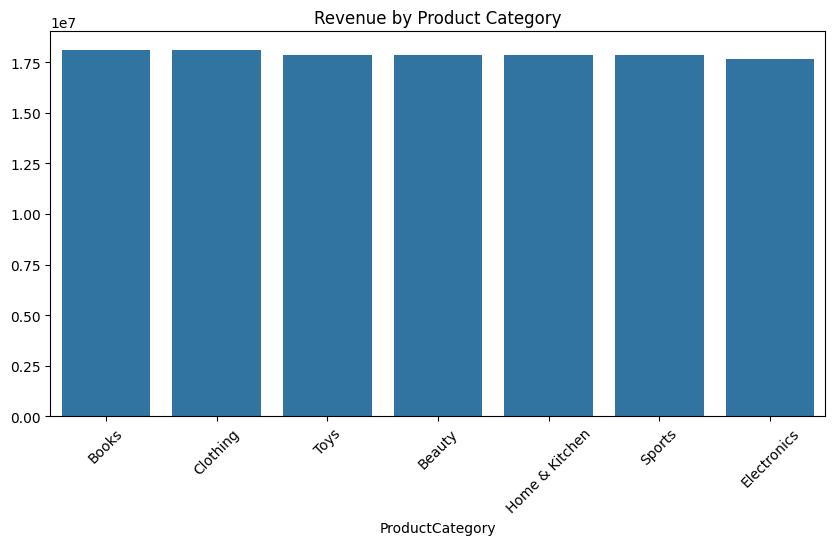

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.xticks(rotation=45)
plt.title("Revenue by Product Category")
plt.show()

PaymentMethod
Bank Transfer       20227
Debit Card          19978
Credit Card         19957
PayPal              19937
Cash on Delivery    19901
Name: count, dtype: int64


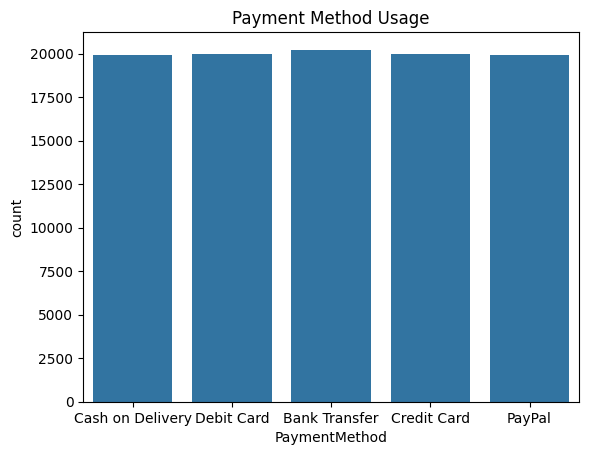

In [10]:
payment = (
    df["PaymentMethod"]
      .value_counts()
)
print(payment)
sns.countplot(
    data=df,
    x="PaymentMethod"
)

plt.title("Payment Method Usage")
plt.show()

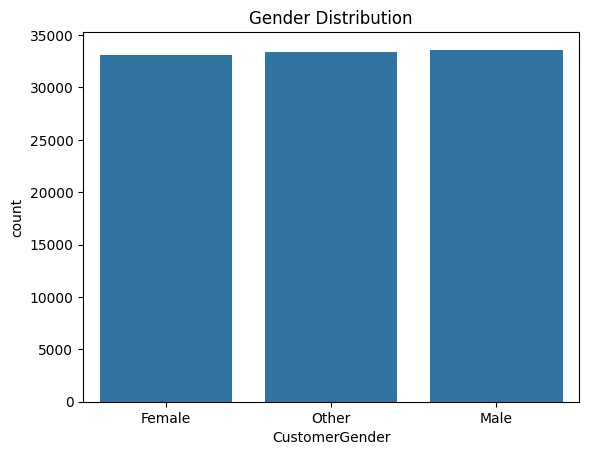

In [17]:
sns.countplot(
    data=df,
    x="CustomerGender"
)

plt.title("Gender Distribution")
plt.show()

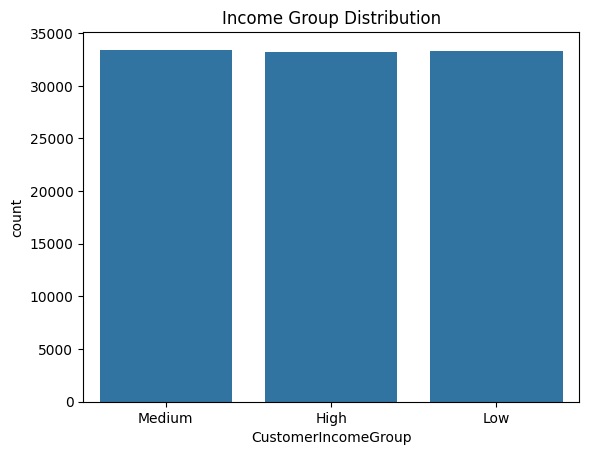

In [18]:
sns.countplot(
    data=df,
    x="CustomerIncomeGroup"
)

plt.title("Income Group Distribution")
plt.show()

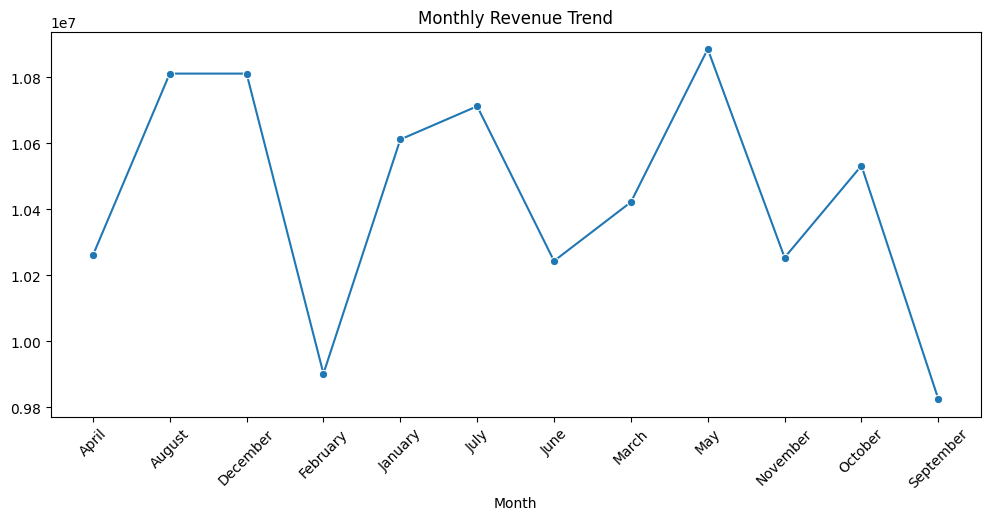

In [19]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

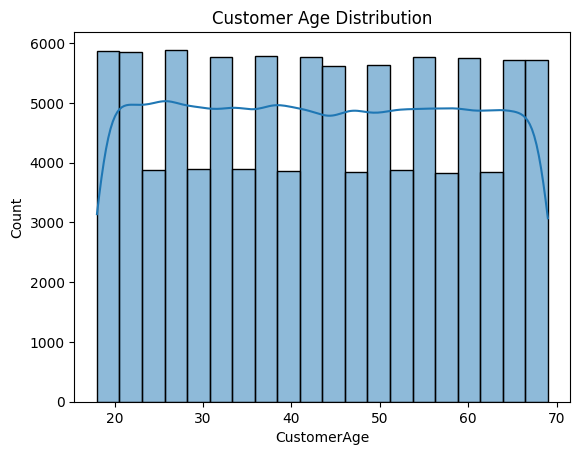

In [20]:
sns.histplot(
    df["CustomerAge"],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.show()

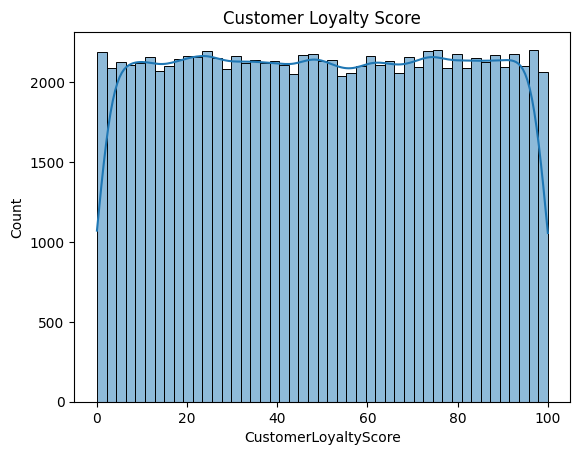

In [21]:
sns.histplot(
    df["CustomerLoyaltyScore"],
    kde=True
)

plt.title("Customer Loyalty Score")
plt.show()

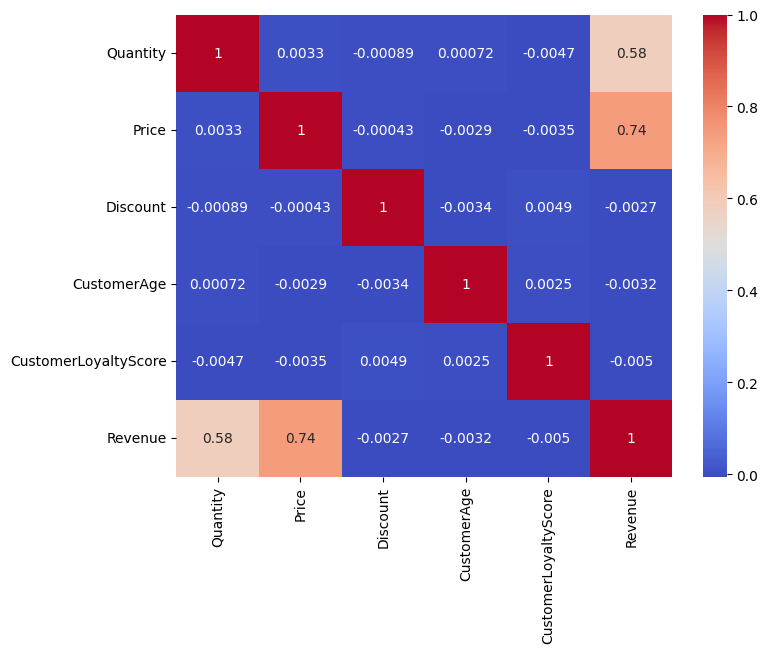

In [22]:
corr = df[
    [
        "Quantity",
        "Price",
        "Discount",
        "CustomerAge",
        "CustomerLoyaltyScore",
        "Revenue"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

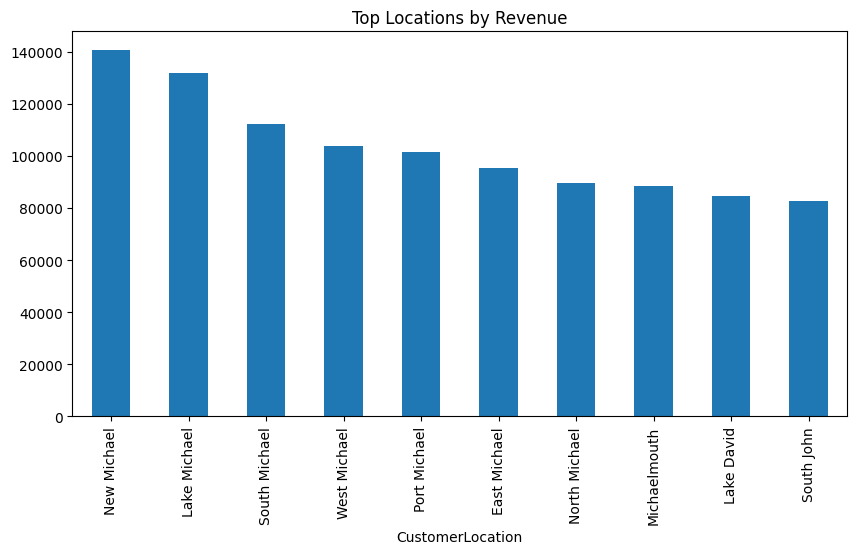

In [23]:
location_sales = (
    df.groupby("CustomerLocation")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
location_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Locations by Revenue")
plt.show()

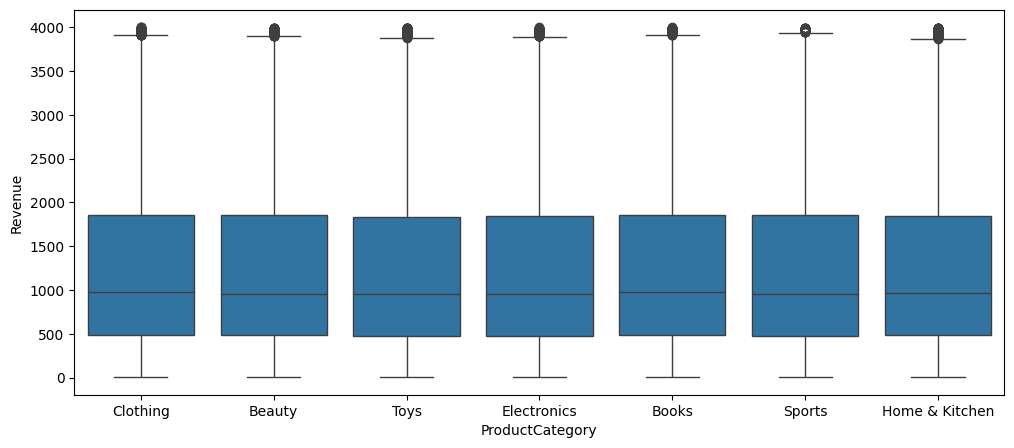

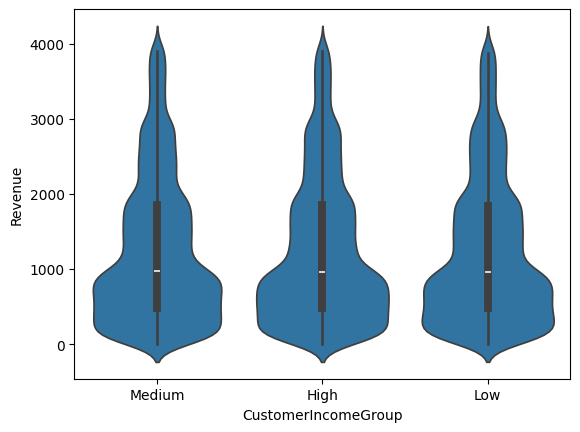

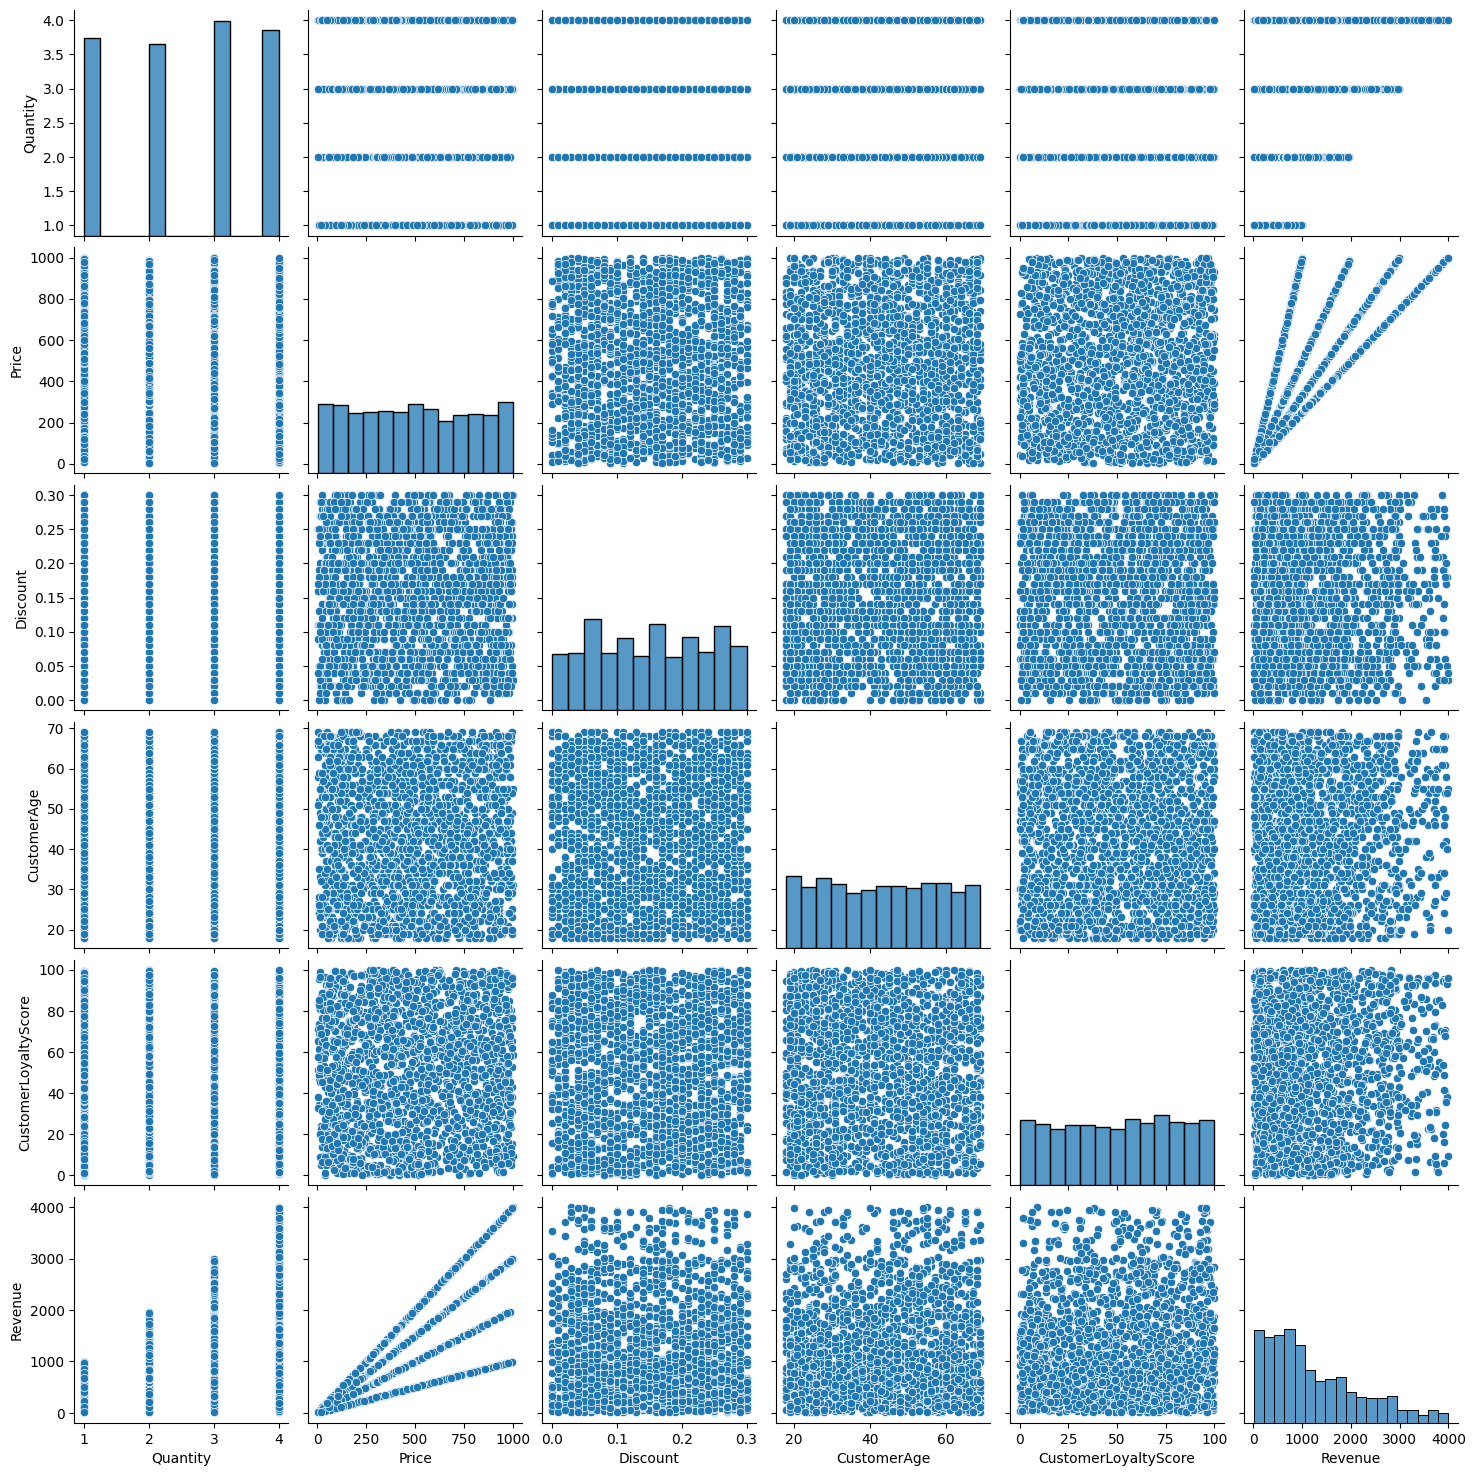

In [26]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="ProductCategory",
    y="Revenue"
)
plt.show()


sns.violinplot(
    data=df,
    x="CustomerIncomeGroup",
    y="Revenue"
)
plt.show()

sns.pairplot(
    df.sample(2000)[
        [
            "Quantity",
            "Price",
            "Discount",
            "CustomerAge",
            "CustomerLoyaltyScore",
            "Revenue"
        ]
    ]
)
plt.xticks(rotation=45)
plt.show()